In [2]:
import torch
from transformers import ViTForImageClassification, ViTImageProcessor, ViTConfig
from PIL import Image
import numpy as np


CHECKPOINT_PATH = "Models/vit_crop/checkpoint-32110"
config = ViTConfig.from_pretrained(CHECKPOINT_PATH, output_attentions=True)

inference_model = ViTForImageClassification.from_pretrained(CHECKPOINT_PATH, config=config)
inference_processor = ViTImageProcessor.from_pretrained(CHECKPOINT_PATH)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
inference_model = inference_model.to(device)
inference_model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"Using device: {device}")

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded from Models/vit_crop/checkpoint-32110
Using device: mps


In [3]:
id_to_class = inference_model.config.id2label
class_to_id = inference_model.config.label2id
print(f"Number of classes: {len(id_to_class)}")
print(f"Classes loaded from model configuration")

Number of classes: 60
Classes loaded from model configuration


In [4]:
def predict_fn(images):
    batch_images = []
    for img in images:
        pil_img = Image.fromarray(img.astype('uint8'), 'RGB')
        batch_images.append(pil_img)
        
    inputs = inference_processor(images=batch_images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = inference_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    return probs.cpu().numpy()


In [5]:
def generate_grad_rollout(model, processor, pil_image, target_class_id):

    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    model.eval() 
    outputs = model(**inputs)
    logits = outputs.logits
    attentions = outputs.attentions 
    
    target_logit = logits[0, target_class_id]
    
    model.zero_grad()
    grads = torch.autograd.grad(target_logit, attentions, retain_graph=True, allow_unused=True)
    
    with torch.no_grad():
        num_tokens = attentions[0].shape[-1]
        rollout = torch.eye(num_tokens, device=device) 
        
        for i in range(len(attentions)):
            A_l = attentions[i] 
            G_l = grads[i]      
            
            if G_l is None:
                continue
            
            A_l = A_l.squeeze(0) 
            G_l = G_l.squeeze(0) 
            
            alpha = torch.mean(G_l, dim=(-1, -2))    
            alpha = torch.nn.functional.relu(alpha) 
            
            alpha_sum = torch.sum(alpha)
            if alpha_sum > 0:
                alpha = alpha / alpha_sum
            else:
                alpha = torch.ones_like(alpha) / alpha.shape[0]

            A_l_avg = torch.einsum('h,hsd->sd', alpha, A_l) 
            
            I = torch.eye(num_tokens, device=device)
            A_l_avg = A_l_avg + I
            
            A_l_avg = A_l_avg / A_l_avg.sum(dim=-1, keepdim=True)
            
            rollout = torch.matmul(A_l_avg, rollout)
            
    cls_attention_map = rollout[0, 1:] 
    num_patches_side = int(cls_attention_map.shape[0]**0.5)
    heatmap = cls_attention_map.reshape(num_patches_side, num_patches_side).cpu().numpy()
    
    return heatmap

In [6]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.15) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


True

In [8]:
graph = Neo4jGraph(url="neo4j://127.0.0.1:7687", username=os.getenv("NEO4J_USER"), password=os.getenv("NEO4J_PASSWORD"), enhanced_schema=True)

In [9]:
from langchain_neo4j.chains.graph_qa.cypher import GraphCypherQAChain

llm = ChatGoogleGenerativeAI(
    model="models/gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)

cypher_chain = GraphCypherQAChain.from_llm(
    llm=llm, 
    graph=graph, 
    verbose=True,
    allow_dangerous_requests=True,    
)

In [10]:
ANSWER_GEN_TEMPLATE = """
### Role
You are an expert AI agricultural assistant. Your goal is to provide a clear, actionable, and *relevant* answer to the user's question about their plant.

### Instructions
You will be given three distinct pieces of information:
1.  **`[Original User Question]`**: What the user *actually* asked. This is your primary target.
3.  **`[Retrieved Knowledge]`**: This is a knowledge subgraph providing general context about the diagnosed disease and crop.

### Critical Rules
* Your response MUST directly answer the `[Original User Question]`.
* Be concise and answer only the user query. Do not provide unnecessary elaboration or extra data.
* **DO NOT** try to "confirm" or "validate" the diagnosis using the retrieved knowledge.
* **DO NOT** output phrases like "The provided subgraph does not contain information..." or "I cannot confirm..."
* Use the `[Diagnosis]` to state the "what" and the `[Retrieved Knowledge]` to build the "why" or "how" of your answer.

<context>
{context}
</context>

Question: {question}
Answer:
"""


In [11]:
from langchain_core.prompts import PromptTemplate
ANSWER_GEN_PROMPT = PromptTemplate.from_template(ANSWER_GEN_TEMPLATE)

In [12]:
answer_chain = ANSWER_GEN_PROMPT | llm

In [30]:
CYPHER_SUBGRAPH = """
MATCH (d:Entity {name: $disease})
MATCH (c:Entity {name: $crop})
MATCH (d)-[rA:AFFECTS]->(c)

OPTIONAL MATCH (d)-[rPRESENTS:PRESENTS]->(s:Entity)
OPTIONAL MATCH (d)-[rPATHOGEN:CAUSED_BY]->(p:Entity)
OPTIONAL MATCH (d)-[rTREAT:TREATED_BY]->(t:Entity)

OPTIONAL MATCH (otherD:Entity)-[rOther:AFFECTS]->(c)
WHERE otherD <> d

WITH 
    // Nodes
    COLLECT(DISTINCT d) +
    COLLECT(DISTINCT c) +
    COLLECT(DISTINCT s) +
    COLLECT(DISTINCT p) +
    COLLECT(DISTINCT t) +
    COLLECT(DISTINCT otherD) AS nodes,

    // Rels
    COLLECT(rA) +
    COLLECT(rPRESENTS) +
    COLLECT(rPATHOGEN) +
    COLLECT(rTREAT) +
    COLLECT(rOther) AS rels

RETURN nodes, rels
"""


In [41]:
def get_contextual_subgraph(disease, crop):

    out  = graph.query(CYPHER_SUBGRAPH, params={"disease": disease, "crop" : crop })[0]['rels']
    unique = []
    seen = set()

    for n1, rel, n2 in out:
        key = (n1['name'], rel, n2['name']) 
        
        if key not in seen:
            seen.add(key)
            unique.append((n1, rel, n2))

    return unique

In [ ]:

# diseases = graph.query("MATCH (d:Entity)-[:PRESENTS]->() RETURN COLLECT(DISTINCT d.name) AS names")[0]['names']
# crops     = graph.query("MATCH (c:Entity)<-[:AFFECTS]-() RETURN COLLECT(DISTINCT c.name) AS names")[0]['names']

# diseases = set(diseases)
# crops = set(crops)

# print(crops )

{'Bell Pepper', 'Potato', 'Leaf Rust', 'Alternaria Blotch', 'Northern Leaf Blight', 'Stem', 'Powdery Mildew', 'Orange', 'Peach', 'Yellow Leaf Curl Virus', 'Mosaic Virus', 'Bacterial Spot', 'Crabapple', 'Late Blight', 'Eggplant', 'Early Blight', 'Citrus Greening', 'Grapes', 'Pear', 'Pumpkin', 'Leaf Blight', 'Corn', 'Grey Spot', 'Cotton', 'Grape', 'Hawthorn', 'Soybean', 'Pepper', 'Tomato', 'Strawberry', 'Leaf', 'Seedling', 'Cedar Apple Rust', 'Leaf Mold', 'Shoot', 'Blueberry', 'Septoria Leaf Spot', 'Apple', 'Cherry', 'Fruit', 'Tobacco', 'Squash', 'Cassava', 'Quince', 'Wheat', 'Petiole', 'Scab', 'Root Rot', 'Rice'}


Predicted class: 'Apple,Mosaic Virus' (ID: 8)


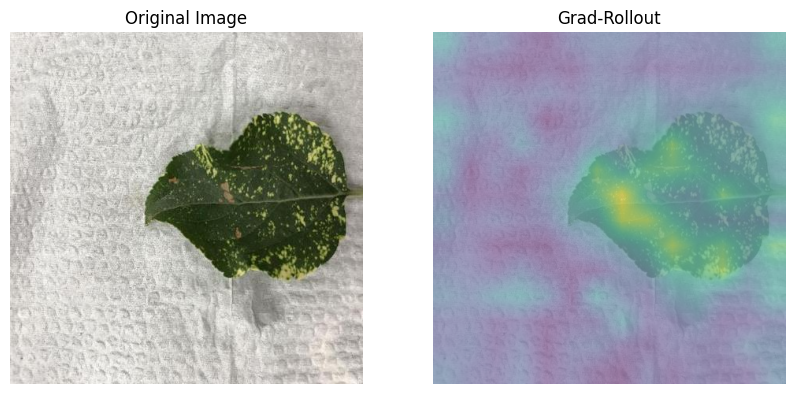

To address Mosaic Virus in your plant, you can use treatments such as cross-protection, disease-free seedlings, Junduqing, Miracid-Morin, Morin-Copper, Morin-Hydroxenene, mushroom polysaccharide, Ningnanmycin, Plant Disease No. II, Triadimefon-Copper-Zinc, Virus No. 1, or Virus No. 2. It is also recommended to remove infected trees.


In [44]:
image = "dataset/images/Apple,Mosaic Virus/plant_103134.jpg" 
query = "how to fix the issue with my plant?"

query_lower = query.lower()

detected_diseases = [d for d in diseases if d.lower() in query_lower]
detected_crops    = [c for c in crops if c.lower() in query_lower]

try:
    image_pil = Image.open(image).convert("RGB")
    image_np = np.array(image_pil)

    probs = predict_fn([image_np])
    predicted_class_id = np.argmax(probs[0])
    predicted_class_name = id_to_class[predicted_class_id]
    print(f"Predicted class: '{predicted_class_name}' (ID: {predicted_class_id})")

    heatmap = generate_grad_rollout(
        inference_model, 
        inference_processor, 
        image_pil, 
        predicted_class_id
    )
    
    import matplotlib.pyplot as plt
    import cv2
    
    img_size = inference_processor.size['height']
    heatmap_resized = cv2.resize(heatmap, (image_pil.width, image_pil.height))
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image_pil)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Grad-Rollout")
    plt.imshow(image_pil, alpha=0.5)
    plt.imshow(heatmap_resized, cmap='viridis', alpha=0.5)
    plt.axis('off')
    plt.show()

    crop, dis = predicted_class_name.split(',')
    subgraph = get_contextual_subgraph(dis, crop)
    answer = answer_chain.invoke({
        "question": query,
        "context": str(subgraph)
    })
    print(answer.content)
    
except FileNotFoundError:
    print(f"Error: Image file not found at '{image}'")
except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure your image file is a valid format (JPG, PNG, etc.)")